# Manual exploration of the datasets created by gpt5.2 and gemini

In [1]:
import sys
from datasets import load_dataset,concatenate_datasets
new_path = r'/home/creux/Documents/AI/VTikz/VariabilityBenchmark'
sys.path.append(new_path)

ds1 = load_dataset("CharlyR/vtikz-evaluation", "simpleLLM_benchmark_openaigpt5.2_pk_1_t_0.7_v1.58",split="tikz")
ds2 = load_dataset("CharlyR/vtikz-evaluation", "simpleLLM_benchmark_googlegemini3propreview_pk_1_t_0.7_v1.58",split="tikz")
ds = concatenate_datasets([ds1,ds2])
df =ds.to_pandas()


/home/creux/miniconda3/envs/varbench/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
any(metric==100 for metric in df["TemplateMetric"][0][0])

True

In [ ]:
import numpy as np
df = df[df["TemplateMetric"].apply(
    lambda metrics: all(len(metric) > 0 and metric[0] != 100 for metric in metrics)
)]
i=  80

In [9]:
from IPython.display import HTML, display
import base64

def display_images_row(*img_jsons, max_height=300, margin=10):
    imgs = []
    for img in img_jsons:
        if img is None:
            continue
        b64 = base64.b64encode(img["bytes"]).decode("utf-8")
        imgs.append(
            f"<img src='data:image/png;base64,{b64}' "
            f"style='max-height:{max_height}px; margin-right:{margin}px;'>"
        )
    html = "<div style='display:flex; align-items:center;'>" + "".join(imgs) + "</div>"
    display(HTML(html))



In [193]:
i-=  1

In [11]:
import difflib

def single_patch(input: str, prediction: str) -> str:
    """Generates a patch from the given input(which will be splitted) and the prediction"""
    solution_split = prediction.splitlines()
    input_split = input.splitlines()
    current_diff = "\n".join(
        list(difflib.unified_diff(input_split, solution_split, n=0))[2:]
    )
    return current_diff


Move the coordinate system between the top EA and F.
beam_coord_change



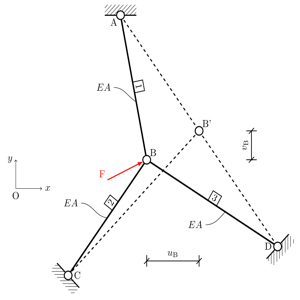
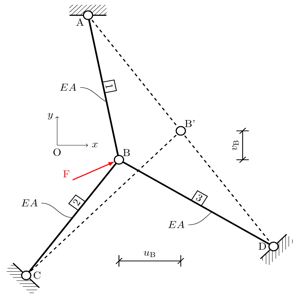
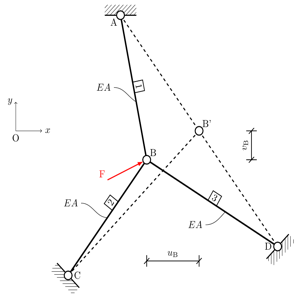

@@ -10,2 +10,2 @@

-\draw (-2,3) node[below] {O};
-\draw[<->] (-1,3) node[right] {$x$}-|(-2,4) node[left]{$y$};
+\draw (-2,5) node[below] {O};
+\draw[<->] (-1,5) node[right] {$x$}-|(-2,6) node[left]{$y$};


In [211]:
i+=1
row = df.iloc[i]
print(row["instruction"])
print(row["id"])
display_images_row(
    row["image_input"],
    row["image_solution"][0],
    row["images_result"][0],
)
open("pred.tex","w").write(row["predictions"][0])
d1 =single_patch(row["code"],row["predictions"][0])
print(d1)

In [209]:
d2=single_patch(row["code"],row["template_solution_code"][0])
print(d2)


@@ -28 +28 @@

-\spy[red] on (2.7,1.5) in node at (1,1.7);
+\spy[red] on (2.69,1.55) in node at (1,1.7);


In [210]:
from vtikz.evaluation.template import template_valid,create_default
from vtikz.dataset_workflow.utils import uncomment_code,unify_code


th_fil = unify_code(uncomment_code((open("/home/creux/Documents/AI/VTikz/VariabilityBenchmark/dataset/tikz/benchmark/zoomedtriangle_centered/solutions/solution3.tex").read())))
template_valid(th_fil,row["predictions"][0])

True

In [ ]:

[open(f"solution{i}.tex","w").write(template) for i,template in enumerate(row["template_solution_code"])]

[template_valid(template,row["predictions"][0]) for template in row["template_solution_code"]]

[False, False, False]

In [170]:
print(single_patch(th_fil,row["predictions"][0]))


@@ -1 +1 @@

-\documentclass[tikz,border=2pt]{standalone}
+\documentclass[tikz,border=5]{standalone}
@@ -7 +7 @@

-\definecolor{§def(lust)}{rgb}{§range(0,0.6,0.13), §rangei(0.9,0.1), §range(0,0.6,0.13)}
+\definecolor{lust}{rgb}{0.0, 0.8, 0.0}
